<a href="https://colab.research.google.com/github/vucse241fa04b96-lang/CodeAlpha-Tasks/blob/main/Task1_Web_Scraping/Task1_Web_Scraping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 CodeAlpha Internship – Task 1

## Web Scraping and Custom Dataset Creation Using Python

### 1.Introduction

Web scraping is the automated process of collecting useful information from websites using programming techniques.

In this project, a publicly available practice website called "Books to Scrape" is used to collect book-related information. Python Requests is used to retrieve webpage content, BeautifulSoup is used to parse the HTML structure, and Pandas is used to organize and clean the collected data.

The final scraped information is converted into a structured dataset and saved as a CSV file for further analysis.

## 2.Libraries Used

The following Python libraries are used in this project:

- Requests – To send HTTP requests and retrieve webpage content.
- BeautifulSoup – To parse HTML and extract required information.
- Pandas – To create, clean, and analyze the dataset.
- Matplotlib – To visualize the collected data.

In [ ]:
!pip install requests beautifulsoup4 pandas matplotlib

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

print("All required libraries imported successfully!")

All required libraries imported successfully!


## 3.Website Selection

For this project, the "Books to Scrape" website is selected as the data source.

Website: https://books.toscrape.com/

This website is designed for practicing web scraping and contains publicly accessible information about books.

The following attributes will be collected:

1. Book Title
2. Price
3. Rating
4. Availability
5. Product URL

In [ ]:
url = "https://books.toscrape.com/"

print("Target Website:")
print(url)

Target Website:
https://books.toscrape.com/


## 4.Sending HTTP Request

An HTTP GET request is sent to the selected webpage using the Requests library.

The response contains the HTML content of the webpage, which will be processed in the next step.

In [ ]:
response = requests.get(url)

print("HTTP Status Code:", response.status_code)

HTTP Status Code: 200


## 5.HTML Parsing Using BeautifulSoup

BeautifulSoup is used to parse the HTML content received from the webpage.

The HTML parser converts the webpage content into a searchable structure, allowing us to locate specific elements such as book titles, prices, ratings, and availability.

In [ ]:
soup = BeautifulSoup(response.text, "html.parser")

print("HTML parsing completed successfully!")

HTML parsing completed successfully!


## 6.Understanding the HTML Structure

Each book on the website is represented using an HTML `article` element with the class `product_pod`.

Inside each book container, important information such as title, price, rating, availability, and product link is available.

BeautifulSoup methods such as `find()` and `find_all()` are used to locate these HTML elements.

In [ ]:
books = soup.find_all(
    "article",
    class_="product_pod"
)

print("Number of books found on the page:", len(books))

Number of books found on the page: 20


In [ ]:
first_book = books[0]

print(first_book.prettify()[:3000])

<article class="product_pod">
 <div class="image_container">
  <a href="catalogue/a-light-in-the-attic_1000/index.html">
   <img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/>
  </a>
 </div>
 <p class="star-rating Three">
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
 </p>
 <h3>
  <a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">
   A Light in the ...
  </a>
 </h3>
 <div class="product_price">
  <p class="price_color">
   Â£51.77
  </p>
  <p class="instock availability">
   <i class="icon-ok">
   </i>
   In stock
  </p>
  <form>
   <button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">
    Add to basket
   </button>
  </form>
 </div>
</article>



## 7.Multiple Page Scraping

To create a larger and more useful dataset, multiple pages of the website are scraped.

The website provides book information across multiple pages. A loop is used to navigate through pages 1 to 5 and collect information from each page.

The following information is extracted:

- Book Title
- Price
- Rating
- Availability
- Product URL

In [ ]:
all_data = []

base_url = "https://books.toscrape.com/catalogue/page-{}.html"

for page in range(1, 6):

    page_url = base_url.format(page)

    response = requests.get(page_url)

    if response.status_code != 200:
        print(f"Failed to access page {page}")
        continue

    soup = BeautifulSoup(
        response.text,
        "html.parser"
    )

    books = soup.find_all(
        "article",
        class_="product_pod"
    )

    for book in books:

        # Extract book title
        title = book.h3.a["title"]

        # Extract price
        price = book.find(
            "p",
            class_="price_color"
        ).get_text(strip=True)

        # Extract rating
        rating = book.find(
            "p",
            class_="star-rating"
        )["class"][1]

        # Extract availability
        availability = book.find(
            "p",
            class_="instock availability"
        ).get_text(" ", strip=True)

        # Extract product URL
        product_url = book.h3.a["href"]

        # Store extracted information
        all_data.append({
            "Title": title,
            "Price": price,
            "Rating": rating,
            "Availability": availability,
            "Product_URL": product_url
        })

    print(
        f"Page {page} completed - "
        f"Total records: {len(all_data)}"
    )

print("\nScraping completed successfully!")

Page 1 completed - Total records: 20
Page 2 completed - Total records: 40
Page 3 completed - Total records: 60
Page 4 completed - Total records: 80
Page 5 completed - Total records: 100

Scraping completed successfully!


## 8.Creating a Pandas DataFrame

The scraped information is stored in a Python list.

The list is converted into a Pandas DataFrame to represent the collected information in a structured tabular format.

In [ ]:
df = pd.DataFrame(all_data)

print("Dataset created successfully!")
print("Number of records:", len(df))
print("Number of columns:", len(df.columns))

Dataset created successfully!
Number of records: 100
Number of columns: 5


In [ ]:
df.head()

,Title,Price,Rating,Availability,Product_URL
0,A Light in the Attic,Â£51.77,Three,In stock,a-light-in-the-attic_1000/index.html
1,Tipping the Velvet,Â£53.74,One,In stock,tipping-the-velvet_999/index.html
2,Soumission,Â£50.10,One,In stock,soumission_998/index.html
3,Sharp Objects,Â£47.82,Four,In stock,sharp-objects_997/index.html
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock,sapiens-a-brief-history-of-humankind_996/index...


## 9.Data Cleaning

The raw scraped data may contain currency symbols, categorical rating values, duplicate records, or unnecessary whitespace.

The following cleaning operations are performed:

- Remove the currency symbol from prices.
- Convert price values into numeric format.
- Convert rating words into numerical values.
- Clean availability text.
- Remove duplicate records.
- Reset the DataFrame index.

In [ ]:
df["Price"] = (
    df["Price"]
    .str.replace("Â", "", regex=False)
    .str.replace("£", "", regex=False)
    .str.strip()
    .astype(float)
)

print("Price column cleaned successfully!")

Price column cleaned successfully!


In [ ]:
df.head()

,Title,Price,Rating,Availability,Product_URL
0,A Light in the Attic,51.77,Three,In stock,a-light-in-the-attic_1000/index.html
1,Tipping the Velvet,53.74,One,In stock,tipping-the-velvet_999/index.html
2,Soumission,50.10,One,In stock,soumission_998/index.html
3,Sharp Objects,47.82,Four,In stock,sharp-objects_997/index.html
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock,sapiens-a-brief-history-of-humankind_996/index...


In [ ]:
#Convert Rating
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)

print("Rating column converted to numerical values!")

Rating column converted to numerical values!


In [ ]:
#Clean Availability
df["Availability"] = (
    df["Availability"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("Availability column cleaned!")

Availability column cleaned!


In [ ]:
#Remove duplicates
before = len(df)

df.drop_duplicates(inplace=True)

after = len(df)

print("Duplicates removed:", before - after)

Duplicates removed: 0


In [ ]:
#Reset Index
df.reset_index(drop=True, inplace=True)

print("Dataset index reset successfully!")

Dataset index reset successfully!


In [ ]:
#Check Missing Values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Title           0
Price           0
Rating          0
Availability    0
Product_URL     0
dtype: int64


## 10.Dataset Analysis

After cleaning the dataset, basic analysis is performed to understand the collected book information.

The analysis includes:

- Dataset dimensions
- Statistical summary
- Most expensive books
- Highest-rated books
- Rating distribution

In [ ]:
#Dataset Shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 100
Columns: 5


In [ ]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         100 non-null    object 
 1   Price         100 non-null    float64
 2   Rating        100 non-null    int64  
 3   Availability  100 non-null    object 
 4   Product_URL   100 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 4.0+ KB


In [ ]:
#Statistical Summary
df.describe()

,Price,Rating
count,100.000000,100.000000
mean,34.560700,2.930000
std,14.638531,1.423149
min,10.160000,1.000000
25%,19.897500,2.000000
50%,34.775000,3.000000
75%,47.967500,4.000000
max,58.110000,5.000000


In [ ]:
#Most Expensive Books
df.sort_values(
    by="Price",
    ascending=False
).head(10)

,Title,Price,Rating,Availability,Product_URL
68,The Death of Humanity: and the Case for Life,58.11,4,In stock,the-death-of-humanity-and-the-case-for-life_93...
40,Slow States of Collapse: Poems,57.31,3,In stock,slow-states-of-collapse-poems_960/index.html
15,Our Band Could Be Your Life: Scenes from the A...,57.25,3,In stock,our-band-could-be-your-life-scenes-from-the-am...
58,The Past Never Ends,56.50,4,In stock,the-past-never-ends_942/index.html
57,The Pioneer Woman Cooks: Dinnertime: Comfort C...,56.41,1,In stock,the-pioneer-woman-cooks-dinnertime-comfort-cla...
91,Masks and Shadows,56.40,2,In stock,masks-and-shadows_909/index.html
56,The Secret of Dreadwillow Carse,56.13,1,In stock,the-secret-of-dreadwillow-carse_944/index.html
67,The Electric Pencil: Drawings from Inside Stat...,56.06,1,In stock,the-electric-pencil-drawings-from-inside-state...
25,Birdsong: A Story in Pictures,54.64,3,In stock,birdsong-a-story-in-pictures_975/index.html
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,sapiens-a-brief-history-of-humankind_996/index...


In [ ]:
#High Rated Books
df.sort_values(
    by="Rating",
    ascending=False
).head(10)

,Title,Price,Rating,Availability,Product_URL
12,Set Me Free,17.46,5,In stock,set-me-free_988/index.html
13,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,5,In stock,scott-pilgrims-precious-little-life-scott-pilg...
14,Rip it Up and Start Again,35.02,5,In stock,rip-it-up-and-start-again_986/index.html
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,sapiens-a-brief-history-of-humankind_996/index...
34,Sophie's World,15.94,5,In stock,sophies-world_966/index.html
32,The Elephant Tree,23.82,5,In stock,the-elephant-tree_968/index.html
24,Black Dust,34.53,5,In stock,black-dust_976/index.html
23,Chase Me (Paris Nights #2),25.27,5,In stock,chase-me-paris-nights-2_977/index.html
28,Worlds Elsewhere: Journeys Around Shakespeareâ...,40.30,5,In stock,worlds-elsewhere-journeys-around-shakespeares-...
30,The Four Agreements: A Practical Guide to Pers...,17.66,5,In stock,the-four-agreements-a-practical-guide-to-perso...


In [ ]:
#Rating Distribution
rating_counts = df["Rating"].value_counts().sort_index()

print(rating_counts)

Rating
1    22
2    19
3    22
4    18
5    19
Name: count, dtype: int64


## 11.Data Visualization

Data visualization helps us understand patterns and distributions in the scraped dataset.

A histogram is used to visualize the distribution of book prices, and a bar chart is used to show the number of books for each rating.

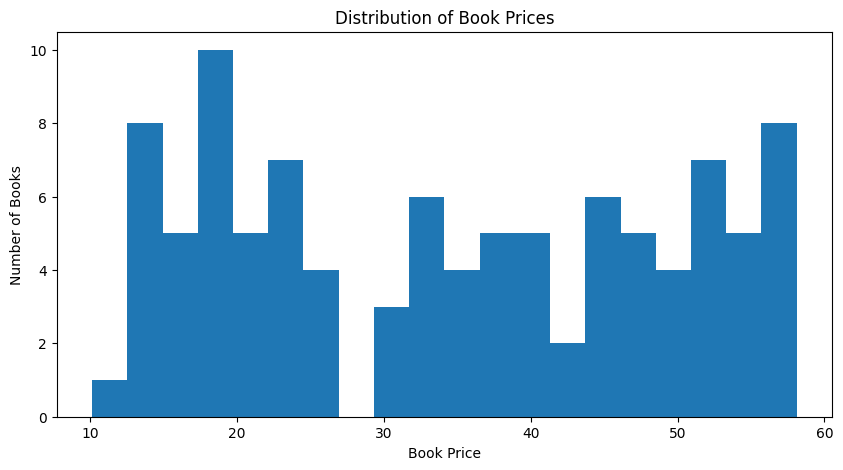

In [ ]:
#Price Distribution
plt.figure(figsize=(10, 5))

plt.hist(
    df["Price"],
    bins=20
)

plt.xlabel("Book Price")
plt.ylabel("Number of Books")
plt.title("Distribution of Book Prices")

plt.show()

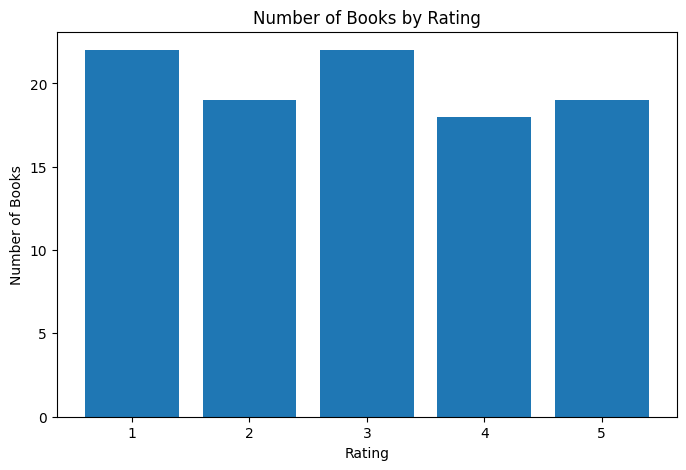

In [ ]:
#Rating Distribution
rating_counts = df["Rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    rating_counts.index,
    rating_counts.values
)

plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.title("Number of Books by Rating")

plt.show()

## 12.Exporting the Dataset to CSV

The final cleaned dataset is exported as a CSV file.

CSV is a commonly used format for storing structured tabular data and can be opened using applications such as Microsoft Excel, Google Sheets, and Python Pandas.

In [ ]:
output_file = "CodeAlpha_Task1_Books_Dataset.csv"

df.to_csv(
    output_file,
    index=False
)

print("Dataset saved successfully!")
print("File name:", output_file)

Dataset saved successfully!
File name: CodeAlpha_Task1_Books_Dataset.csv


In [ ]:
from google.colab import files

files.download(
    "CodeAlpha_Task1_Books_Dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##13.Final Dataset Preview


The final cleaned dataset contains structured information about books collected from multiple webpages.

The dataset includes:

- Title
- Price
- Rating
- Availability
- Product URL

In [ ]:
df.head(20)

,Title,Price,Rating,Availability,Product_URL
0,A Light in the Attic,51.77,3,In stock,a-light-in-the-attic_1000/index.html
1,Tipping the Velvet,53.74,1,In stock,tipping-the-velvet_999/index.html
2,Soumission,50.10,1,In stock,soumission_998/index.html
3,Sharp Objects,47.82,4,In stock,sharp-objects_997/index.html
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,sapiens-a-brief-history-of-humankind_996/index...
5,The Requiem Red,22.65,1,In stock,the-requiem-red_995/index.html
6,The Dirty Little Secrets of Getting Your Dream...,33.34,4,In stock,the-dirty-little-secrets-of-getting-your-dream...
7,The Coming Woman: A Novel Based on the Life of...,17.93,3,In stock,the-coming-woman-a-novel-based-on-the-life-of-...
8,The Boys in the Boat: Nine Americans and Their...,22.60,4,In stock,the-boys-in-the-boat-nine-americans-and-their-...
9,The Black Maria,52.15,1,In stock,the-black-maria_991/index.html


In [ ]:
print("Final Dataset Shape:", df.shape)

Final Dataset Shape: (100, 5)


#14.Conclusion


The CodeAlpha Internship Task 1 was successfully completed using Python-based web scraping techniques.

In this project, Requests was used to retrieve webpage content and BeautifulSoup was used to parse the HTML structure and extract book information. Multiple pages were scraped to create a larger dataset containing book titles, prices, ratings, availability, and product URLs.

The extracted data was cleaned and organized using Pandas. Basic data analysis and visualization were also performed to understand the collected information. Finally, the cleaned dataset was exported as a CSV file for further use.

This project provided practical knowledge of web scraping, HTML structure, web navigation, data extraction, data cleaning, dataset creation, and basic data analysis.